# FedAvg vs FedVARP

In [1]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from plots_utils.quanti import refine_results, plot_mean_seeds_var_over_training, plot_final_best_test_acc, plot_final_best_worst_test_acc

import os

## With fine-tuning

In [2]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist",
    seeds=["42", "78", "84"],
    algorithms=["fedavg", "fedvarp"],
    events=["global"],
    lr_list=["1e-1", "5e-2", "1e-2", "1e-3", "1e-4"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=list(
        "gp-35-tcsu-10ft gp-50-tcsu-10ft gp-35-tusu-10ft gp-50-tusu-10ft gp-35-tcsc-10ft-2 gp-35-tusc-10ft-2 gp-50-tcsc-10ft-2 gp-50-tusc-10ft-2 gp-20304050607080-tcsu-10ft gp-20304050607080-tusu-10ft gp-25255050507575-tcsu-10ft gp-25255050507575-tusu-10ft".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
    batch_sizes=["128"]
)

raw_results = load_experiment_results(config)

refined_res, best_worst_res = refine_results(raw_results)

folder='figures/lr_exp/quanti_analysis/with_ft'
keyword = 'with ft'

Processing experiments:   0%|          | 0/5 [00:00<?, ?it/s]2024-11-06 17:54:07.656185: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-06 17:54:07.668311: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-06 17:54:07.682977: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-06 17:54:07.687396: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-06

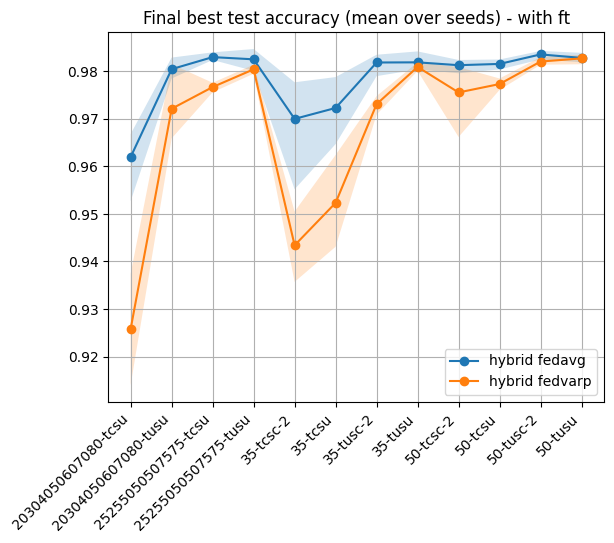

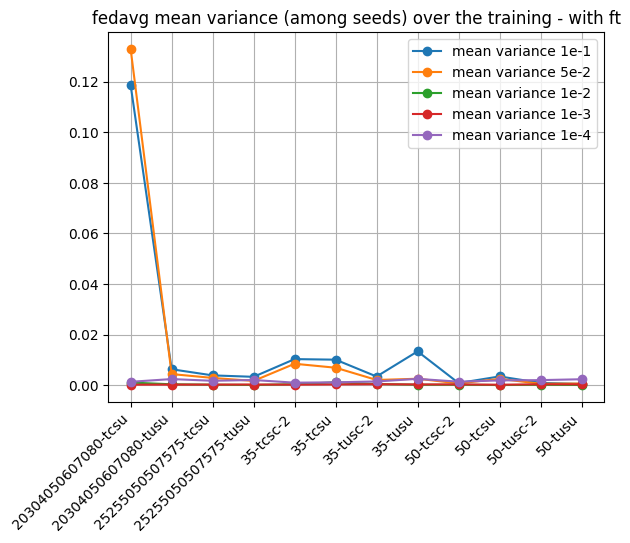

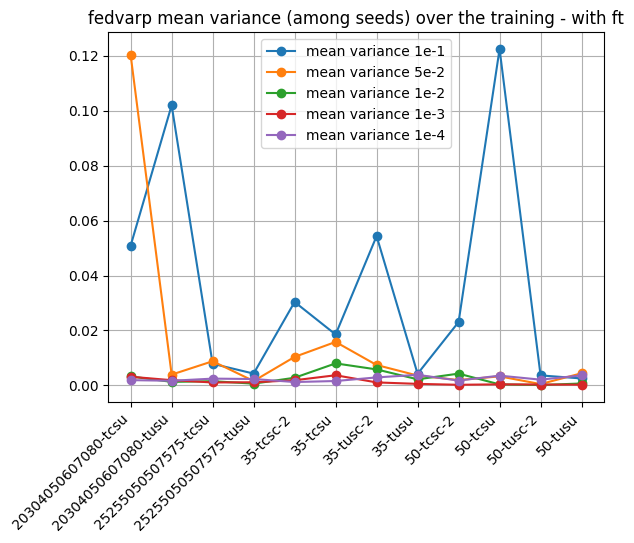

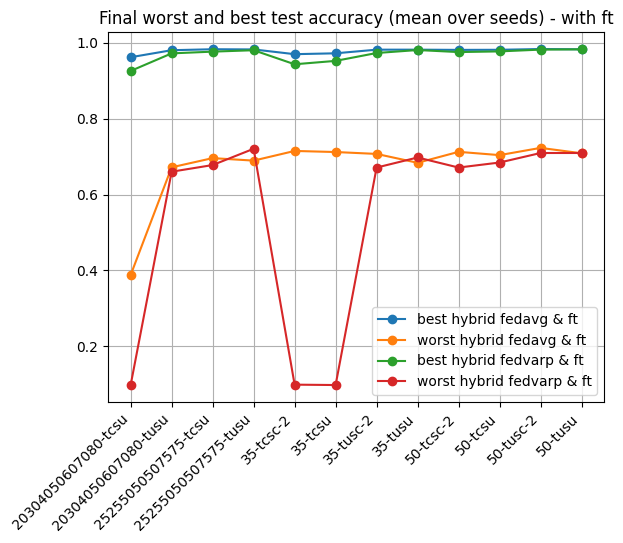

In [3]:
plot_final_best_test_acc(best_worst_res, folder, keyword)
plot_mean_seeds_var_over_training(refined_res, ["1e-1", "5e-2", "1e-2", "1e-3", "1e-4"], folder, keyword)
plot_final_best_worst_test_acc(best_worst_res, folder, keyword)

## Without fine-tuning

In [4]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist",
    seeds=["42", "78", "84"],
    algorithms=["fedavg", "fedvarp"],
    events=["global"],
    lr_list=["5e-2", "1e-2", "1e-3"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=list(
        "gp-35-tcsu gp-50-tcsu gp-35-tusu gp-50-tusu gp-35-tcsc-2 gp-35-tusc-2 gp-50-tcsc-2 gp-50-tusc-2 gp-20304050607080-tcsu gp-20304050607080-tusu gp-25255050507575-tcsu gp-25255050507575-tusu".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
    batch_sizes=["128"]
)

raw_results = load_experiment_results(config)

refined_res, best_worst_res = refine_results(raw_results)

folder='figures/lr_exp/quanti_analysis/without_ft'
keyword='without ft'

Processing experiments: 100%|██████████| 3/3 [00:02<00:00,  1.18it/s]


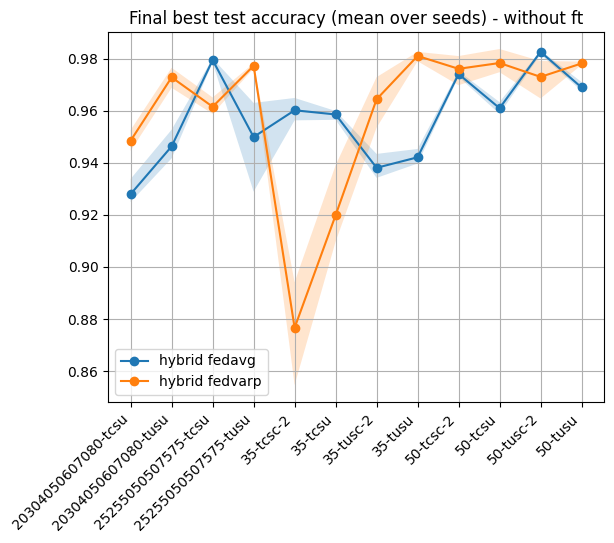

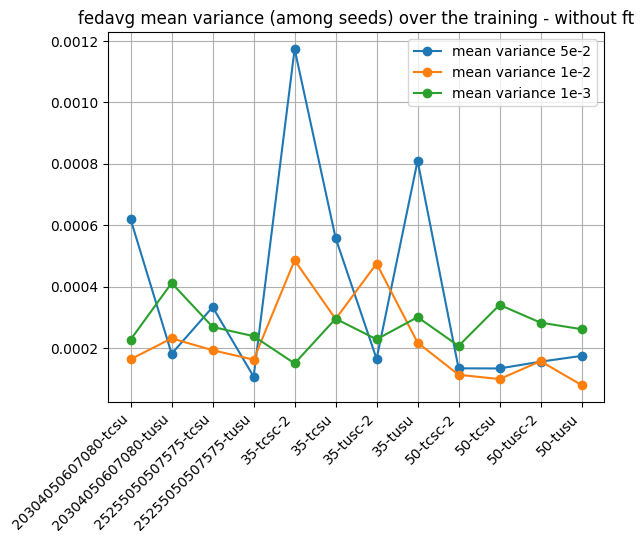

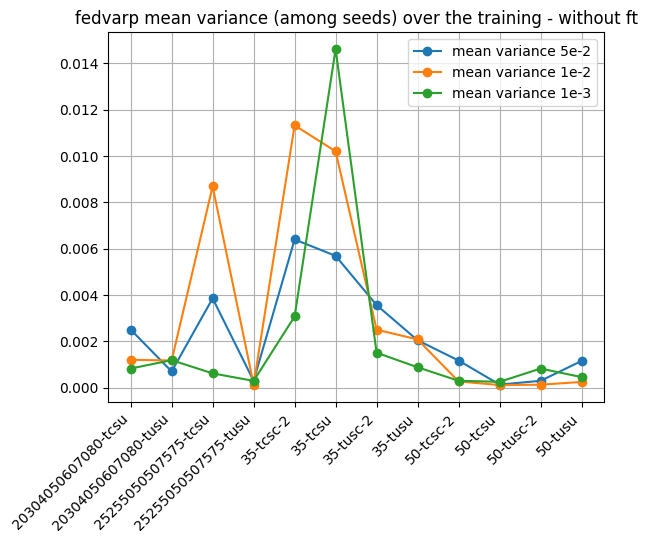

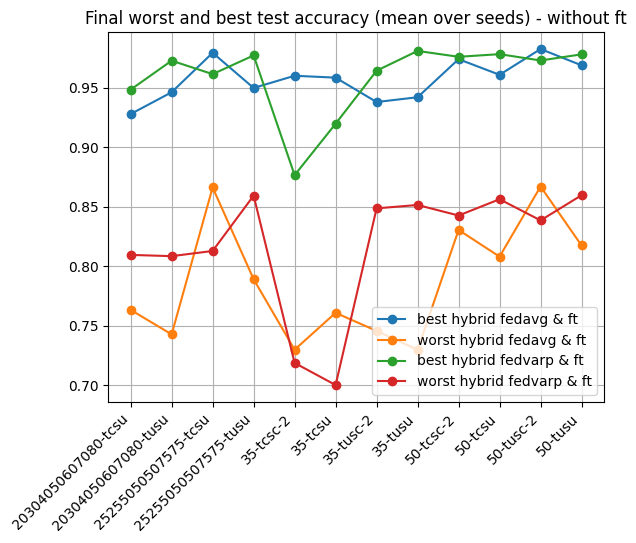

In [5]:
plot_final_best_test_acc(best_worst_res, folder, keyword)
plot_mean_seeds_var_over_training(refined_res, ["5e-2", "1e-2", "1e-3"], folder, keyword)
plot_final_best_worst_test_acc(best_worst_res, folder, keyword)

## Effect of Batch Size

In [6]:
# gp-35-tusu-10ft MISSING AV MAT

config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist",
    seeds=["78", "84"],
    algorithms=["fedavg", "fedvarp"],
    events=["global"],
    lr_list=["1e-2", "5e-2"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=list(
        "gp-35-tcsu-10ft gp-50-tcsu-10ft gp-50-tusu-10ft gp-35-tcsc-10ft-2 gp-35-tusc-10ft-2 gp-50-tcsc-10ft-2 gp-50-tusc-10ft-2 gp-20304050607080-tcsu-10ft gp-20304050607080-tusu-10ft gp-25255050507575-tcsu-10ft gp-25255050507575-tusu-10ft".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
    batch_sizes=["256"]
)

raw_results = load_experiment_results(config)

refined_res, best_worst_res = refine_results(raw_results)

folder='figures/lr_exp/quanti_analysis/batch_256_with_ft'
keyword = 'batch 256 with ft'

Processing experiments: 100%|██████████| 2/2 [00:00<00:00,  2.01it/s]


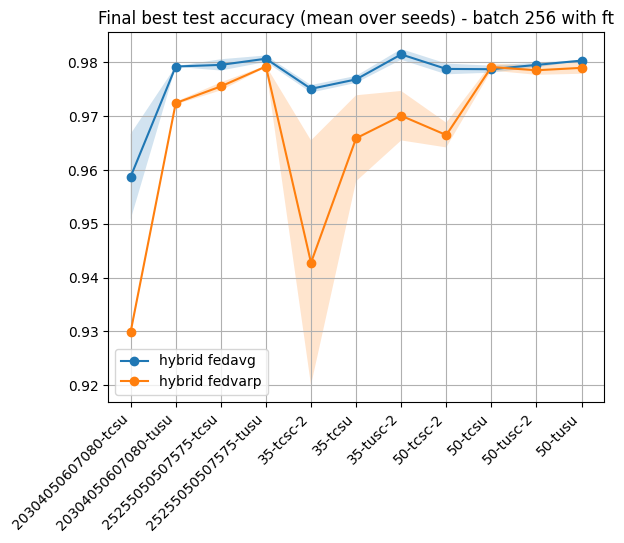

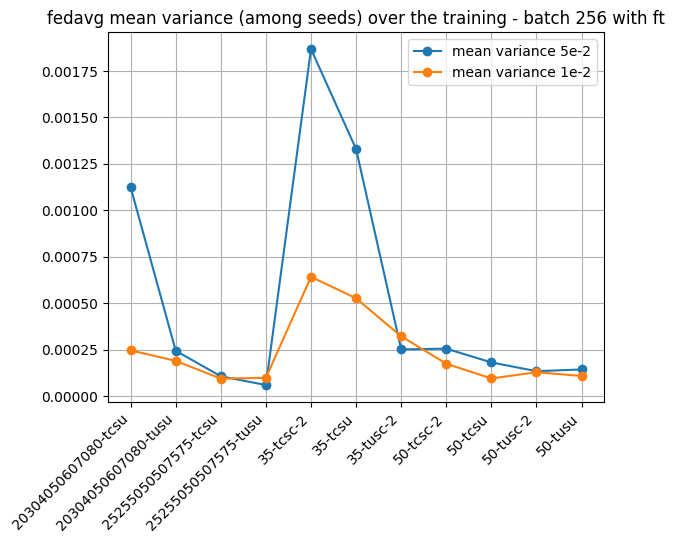

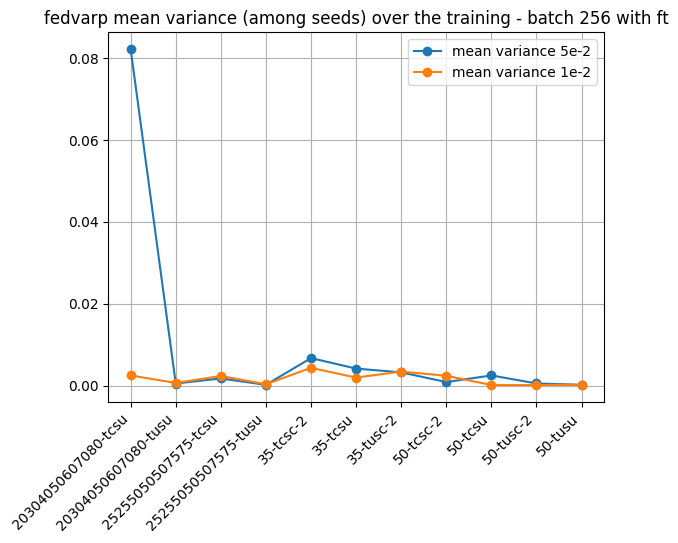

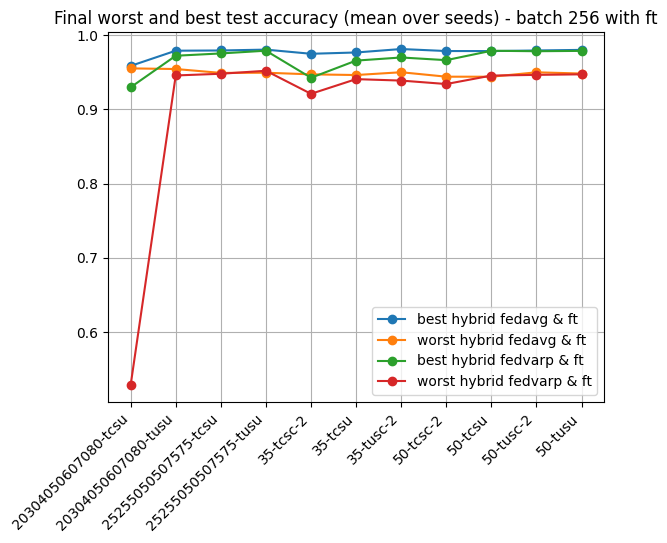

In [8]:
plot_final_best_test_acc(best_worst_res, folder, keyword)
plot_mean_seeds_var_over_training(refined_res, ["5e-2", "1e-2"], folder, keyword)
plot_final_best_worst_test_acc(best_worst_res, folder, keyword)